### BMI Workflow

In [13]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from IPython.display import Image

In [16]:
class BMIState(TypedDict):
    weight_kg: float
    height_m: float
    bmi: float
    category: str

In [20]:
def calculate_bmi(state: BMIState) -> BMIState:
    weight = state['weight_kg']
    height = state['height_m']
    bmi = weight/(height**2)
    
    state['bmi'] = round(bmi, 2)
    return state

In [26]:
def label_bmi(state: BMIState) -> BMIState:
    bmi = state['bmi']

    if bmi < 18.5:
        state['category'] = 'Underweight'
    elif 18.5 <= bmi < 25:
        state['category'] = 'Normal'
    elif 25 <= bmi < 30:
        state['category'] = 'Overweight'
    else:
        state['category'] = 'Obese'

    return state


In [27]:
# Define your Graph
graph = StateGraph(BMIState)

# Add nodes to the Graph
graph.add_node('calculate_bmi', calculate_bmi)
graph.add_node('label_bmi', label_bmi)

# Add Edges to your Graph
graph.add_edge(START, 'calculate_bmi')
graph.add_edge('calculate_bmi', 'label_bmi')
graph.add_edge('label_bmi', END)

# Compile the Graph
workflow = graph.compile()

In [37]:
# Execute the graph
initial_state = {'weight_kg': 40, 'height_m':1.2}
output_state = workflow.invoke(initial_state)

In [38]:
output_state

{'weight_kg': 40, 'height_m': 1.2, 'bmi': 27.78, 'category': 'Overweight'}

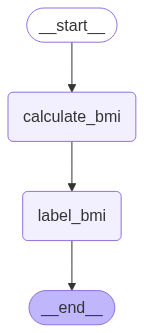

In [39]:
Image(workflow.get_graph().draw_mermaid_png())

### LLM Workflow

In [46]:
from dotenv import load_dotenv
import os
load_dotenv()

True

In [59]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict

In [52]:
model = ChatOpenAI(api_key=os.getenv('OPENAI_API'))
model

ChatOpenAI(client=<openai.resources.chat.completions.completions.Completions object at 0x0000019A576CD090>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x0000019A576CD450>, root_client=<openai.OpenAI object at 0x0000019A57447D10>, root_async_client=<openai.AsyncOpenAI object at 0x0000019A576CD1D0>, model_kwargs={}, openai_api_key=SecretStr('**********'))

In [60]:
# State
class LLMState(TypedDict):
    question: str
    answer: str

In [61]:
def llm_qa(state: LLMState) -> LLMState:
    question = state['question']

    PROMPT = f"Answer the given question {question}"

    answer = model.invoke(PROMPT).content

    state['answer'] = answer

    return state

In [62]:
# Graph
graph = StateGraph(LLMState)

# Nodes
graph.add_node('llm_qa', llm_qa)

# Edges
graph.add_edge(START, 'llm_qa')
graph.add_edge('llm_qa', END)

workflow = graph.compile()

In [64]:
init_state = {'question' : 'Who is the inventor of langgraph'}
goal_state = workflow.invoke(init_state)
goal_state

{'question': 'Who is the inventor of langgraph',
 'answer': 'The inventor of Langgraph is Jure Slatner.'}

### Prompt Chaining

In [65]:
from dotenv import load_dotenv
import os
load_dotenv()

True

In [66]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict

In [67]:
model = ChatOpenAI(api_key=os.getenv('OPENAI_API'))
model

ChatOpenAI(client=<openai.resources.chat.completions.completions.Completions object at 0x0000019A5756F5C0>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x0000019A5756F950>, root_client=<openai.OpenAI object at 0x0000019A576ABDF0>, root_async_client=<openai.AsyncOpenAI object at 0x0000019A5756F6F0>, model_kwargs={}, openai_api_key=SecretStr('**********'))

In [80]:
class BlogState(TypedDict):
    title: str
    outline: str
    content: str

In [82]:
def create_outline(state: BlogState) -> BlogState:
    topic = state['title']

    # Outline
    prompt = f"Generate an outline for a blog on this topic: {topic}"
    outline = model.invoke(prompt).content

    state['outline'] = outline

    return state

In [83]:
def create_blog(state: BlogState) -> BlogState:
    title = state['title']
    outline = state['outline']

    # Content
    prompt = f"Write a detailed blog on the on this title: {title} using the following outline \n {outline}"
    content = model.invoke(prompt).content

    state['content'] = content

    return state
    

In [84]:
graph = StateGraph(BlogState)

graph.add_node('outline', create_outline)
graph.add_node('blog', create_blog)

graph.add_edge(START, 'outline')
graph.add_edge('outline', 'blog')
graph.add_edge('blog', END)

workflow = graph.compile()

In [85]:
initial_state = {'title': 'Agentic AI'}

final_state = workflow.invoke(initial_state)
final_state

{'title': 'Agentic AI',
 'outline': 'I. Introduction\n    A. Explanation of agentic AI\n    B. Importance of agentic AI in various industries\n\nII. What is Agentic AI?\n    A. Definition of agentic AI\n    B. Characteristics of agentic AI\n    C. Examples of agentic AI technology\n\nIII. Applications of Agentic AI\n    A. Agentic AI in business\n    B. Agentic AI in healthcare\n    C. Agentic AI in transportation\n    D. Agentic AI in other industries\n\nIV. Advantages of Agentic AI\n    A. Improved efficiency\n    B. Enhanced decision-making\n    C. Increased productivity\n    D. Cost savings\n\nV. Challenges of Agentic AI\n    A. Ethical concerns\n    B. Security risks\n    C. Job displacement\n    D. Lack of regulation\n\nVI. Future of Agentic AI\n    A. Potential advancements and innovations\n    B. Impact on society\n    C. Ways to navigate the challenges of agentic AI\n\nVII. Conclusion\n    A. Recap of the importance of agentic AI\n    B. Final thoughts on the future of AI and 

In [89]:
print(final_state['content'])



I. Introduction

A. Explanation of agentic AI
Artificial Intelligence (AI) is a rapidly growing field that encompasses the development of machines and systems that can perform tasks that typically require human intelligence. Agentic AI refers to AI systems that are capable of autonomous decision-making and action, without the need for human intervention. This type of AI has the ability to operate independently and take initiative, making it an important tool in various industries.

B. Importance of agentic AI in various industries
Agentic AI has the potential to revolutionize industries by streamlining processes, increasing efficiency, and reducing costs. It can perform tasks at speeds and scales that are impossible for humans, leading to improved productivity and decision-making. From healthcare to transportation to business operations, agentic AI has vast applications that can benefit society as a whole.

II. What is Agentic AI?

A. Definition of agentic AI
Agentic AI refers to AI 